In [218]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from utils.trainer import create_model, DEVICE
from utils.optimization_utils import *

# Root directory for all results
BASE_DIR = Path("./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000")


In [227]:
main_result_path = {
    "vanilla":
    [
        "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
        "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
        "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
        "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
    ],
    # [
    #     "20260328-211058_MLP_FSNet_seed0_nepochs1000_lr0.0001_trainsize7000",
    #     "20260328-211058_MLP_FSNet_seed3_nepochs1000_lr0.0001_trainsize7000",
    #     "20260328-211058_MLP_FSNet_seed1_nepochs1000_lr0.0001_trainsize7000",
    #     "20260328-211058_MLP_FSNet_seed2_nepochs1000_lr0.0001_trainsize7000",
    # ],
    "pretraining":
    [
        "20260327-092838_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_3.0",
    ],
    'epoch 100':
    [
        # "20260506-031006_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_100",
        "20260506-042445_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_100",
        "20260506-041120_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_100",
        "20260506-042425_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_100",
    ],
    'epoch 200':
    [
        "20260506-050848_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_200",
        "20260506-050856_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_200",
        "20260506-050904_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_200",
        "20260506-053547_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_200",
    ],
    'epoch 300*':
    [
        "20260506-031229_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_300",
        "20260506-043400_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_300",
        "20260506-042219_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_300",
        "20260506-043308_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_300",
    ],
    'epoch 400':
    [
        "20260506-051639_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_400",
        "20260506-051323_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_400",
        "20260506-051311_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_400",
        "20260506-054014_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_400",
    ],
    'epoch 500':
    [
        "20260506-031704_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_500",
        "20260506-043804_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_500",
        "20260506-043037_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_500",
        "20260506-043714_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_500",
    ],
    'epoch 600':
    [
        "20260506-052107_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_600",
        "20260506-051724_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_600",
        "20260506-051817_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_600",
        "20260506-054518_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_600",
    ],
    'epoch 700':
    [
        "20260506-032141_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_700",
        "20260506-044214_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_700",
        "20260506-043803_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_700",
        "20260506-044159_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_700",
    ],
    'epoch 800':
    [
        "20260506-052502_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_800",
        "20260506-052404_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_800",
        "20260506-052215_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_800",
        "20260506-055057_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_800",
    ],
    'epoch 900':
    [
        "20260506-032718_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_900",
        "20260506-044623_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_900",
        "20260506-044226_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_900",
        "20260506-044546_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_900",
    ],
    'epoch 990':
    [
        "20260506-052919_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_990",
        "20260506-052736_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_990",
        "20260506-052846_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_990",
        "20260506-055428_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-092838_sup_seedpen_model_990",
    ],
}

# main_result_path = {
#     "vanilla":
#     [
#         "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
#         # "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
#         "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
#         "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
#     ],
#     "pretraining":
#     [
#         "20260115-184954_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_2.0",
#     ],
#     'ours':
#     [
# "20260118-060443_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990",
# # "20260118-055607_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990",
# "20260118-050530_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990",
# "20260118-050045_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990"
#     ], # 3.0
# }

In [228]:
# --- Functions ---
def load_results(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_metrics(results, history_key='val_history'):
    if history_key not in results or not results[history_key]:
        return None
    metrics = {k: [] for k in results[history_key][0].keys()}
    for entry in results[history_key]:
        for key in metrics.keys():
            metrics[key].append(entry[key])
    return {k: np.array(v) for k, v in metrics.items()}

def load_and_recompute(result_paths, base_path):
    data_tree = {}
    for method, folders in result_paths.items():
        data_tree[method] = []
        for folder in folders:
            p = base_path / folder / "results.pkl"
            if p.exists():
                res = load_results(p)
                m = get_metrics(res, 'val_history')
                eq_weight = 1e5
                ineq_weight = 1e5   
                
                # Recompute Merit Mean using requested keys
                m['recomputed_merit_mean'] = (
                    m['objective'] + 
                    eq_weight * m['eq_violation_l1_mean'] + ineq_weight * m['ineq_violation_l1_mean']
                )
                
                m['recomputed_merit_max'] = (
                    m['objective_max'] + 
                    eq_weight * m['eq_violation_l1_max'] + ineq_weight * m['ineq_violation_l1_max']
                )
                
                # m['recomputed_merit_mean'] = (
                #     m['merit_mean']
                # )
                
                # m['recomputed_merit_max'] = (
                #     m['merit_max']
                # )
                data_tree[method].append(m)
            else:
                print(f"Warning: Path not found {p}")
    return data_tree

In [229]:
processed_data = load_and_recompute(main_result_path, BASE_DIR)

In [230]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, ScalarFormatter

FONT_SIZE = 24
LINE_WIDTH = 3

# Use two palettes:
# - FILL_COLORS: light (for bands)
# - LINE_COLORS: darker (for strokes, markers, annotation)
FILL_COLORS = {
    "vanilla": "#F2B8A2",      # light peach
    "pretraining": "#086EB6",#"#000000",  # light steel-blue
    "epoch 100": "#AFAFAF",         # light teal-green
    "epoch 200": "#AFAFAF",         # light teal-green
    "epoch 300*": "#BFE5D3",         # light teal-green
    "epoch 400": "#AFAFAF",         # light teal-green
    "epoch 500": "#AFAFAF",         # light teal-green
    "epoch 600": "#AFAFAF",         # light teal-green
    "epoch 700": "#AFAFAF",         # light teal-green
    "epoch 800": "#AFAFAF",         # light teal-green
    "epoch 900": "#AFAFAF",         # light teal-green
    "epoch 990": "#AFAFAF",         # light teal-green
}
LINE_COLORS = {
    "vanilla": "#C97D77",     # muted brick red
    "pretraining": "#086EB6", # steel blue
    "epoch 50": "#818181",        # sage green (updated)
    "epoch 300*": "#6E8F71",        # sage green (updated)
    "epoch 100": "#818181",        # sage green (updated)
    "epoch 200": "#818181",        # sage green (updated)
    "epoch 400": "#818181",        # sage green (updated)
    "epoch 500": "#818181",        # sage green (updated)
    "epoch 600": "#818181",        # sage green (updated)
    "epoch 700": "#818181",        # sage green (updated)
    "epoch 800": "#818181",        # sage green (updated)
    "epoch 900": "#818181",        # sage green (updated)
    "epoch 990": "#818181",        # sage green (updated)
}
STYLES = {"vanilla": "-", "pretraining": "-", "epoch 100": "--", "epoch 200": "--", "epoch 300*": "-", "epoch 400": "--", "epoch 500": "--", "epoch 600": "--", "epoch 700": "--", "epoch 800": "--", "epoch 900": "--", "epoch 990": "--"}  # keep your original

def get_val_metrics(results):
    metrics = get_metrics(results, 'val_history')
    return metrics

def get_train_metrics(results):
    metrics = get_metrics(results, 'train_history')
    if metrics is None:
        return None
    return metrics

_SL_VAL_PROBLEM_CACHE = {}
_SL_VAL_SUP_PEN_LOSS_CACHE = {}
_SL_VAL_MERIT_CACHE = {}

def load_problem_for_config(config):
    cache_key = (
        config['prob_type'],
        config['prob_name'],
        tuple(config['prob_size']),
        config['train_size'],
        config['val_size'],
        config['test_size'],
        config['seed'],
        config['en_subopt'],
        config['subopt_ratio'],
        config['method'],
    )
    if cache_key in _SL_VAL_PROBLEM_CACHE:
        return _SL_VAL_PROBLEM_CACHE[cache_key]

    problem_names = {
        'convex': {'qp': QPProblem, 'qcqp': QCQPProblem, 'socp': SOCPProblem},
        'nonconvex': {'qp': nonconvexQPProblem, 'qcqp': nonconvexQCQPProblem, 'socp': nonconvexSOCPProblem},
        'nonsmooth_nonconvex': {
            'qp': nonsmooth_nonconvexQPProblem,
            'qcqp': nonsmooth_nonconvexQCQPProblem,
            'socp': nonsmooth_nonconvexSOCPProblem,
        },
    }
    prob_type = config['prob_type']
    prob_name = config['prob_name']
    prob_size = config['prob_size']
    seed_data = 2025
    dataset_filepath = os.path.join(
        'datasets',
        prob_type,
        prob_name,
        f"random{seed_data}_{prob_name}_dataset_var{prob_size[0]}_ineq{prob_size[1]}_eq{prob_size[2]}_ex{prob_size[3]}",
    )
    if config['method'] in ['sup', 'sup_partial', 'sup_pen', 'S3Net', 'semi']:
        if config['en_subopt'] == 1:
            dataset_filepath += f"_subopt_noise{config['subopt_ratio']}_bias{config['subopt_ratio']}"
        if config['en_subopt'] == 2:
            if config['subopt_ratio'] == 1:
                dataset_filepath += '_tol1e0_ready'
            if config['subopt_ratio'] == -10:
                dataset_filepath += '_tol1em1_ready'
        if config['en_subopt'] == 3:
            dataset_filepath += f"_maxt{config['subopt_ratio']}_ready"

    with open(dataset_filepath, 'rb') as f:
        dataset = pickle.load(f)

    opt_problem = problem_names[prob_type][prob_name](
        dataset,
        config['train_size'],
        config['val_size'],
        config['test_size'],
        config['seed'],
        config['en_subopt'],
    )
    opt_problem.device = DEVICE
    for attr in dir(opt_problem):
        var = getattr(opt_problem, attr)
        if torch.is_tensor(var):
            try:
                setattr(opt_problem, attr, var.to(DEVICE))
            except AttributeError:
                pass

    _SL_VAL_PROBLEM_CACHE[cache_key] = opt_problem
    return opt_problem

def compute_checkpoint_val_sup_pen_loss(result_paths, base_path, sl_epoch, batch_size=256, sup_weight=100.0):
    pretrain_folder = result_paths['pretraining'][0]
    cache_key = (str(base_path), pretrain_folder, sl_epoch, batch_size, sup_weight)
    if cache_key in _SL_VAL_SUP_PEN_LOSS_CACHE:
        return _SL_VAL_SUP_PEN_LOSS_CACHE[cache_key]

    checkpoint_path = base_path / pretrain_folder / f'model_{sl_epoch}.pt'
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Missing supervised checkpoint: {checkpoint_path}')

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    config = checkpoint['config']
    opt_problem = load_problem_for_config(config)
    model = create_model(opt_problem, config['method'], config)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    sup_pen_config = config.get('sup_pen', {})
    eq_weight = sup_pen_config.get('eq_pen_weight', 5.0)
    ineq_weight = sup_pen_config.get('ineq_pen_weight', 5.0)

    def huber(x, delta=1e-1):
        ax = x.abs()
        return torch.where(ax <= delta, 0.5 * x.pow(2) / delta, ax - 0.5 * delta)

    total_loss = 0.0
    total_samples = 0
    val_loader = DataLoader(opt_problem.val_dataset, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for X_batch, Y_label in val_loader:
            X_batch = X_batch.to(DEVICE)
            Y_label = Y_label.to(DEVICE)
            Y_pred = model(X_batch)
            Y_pred_scaled = opt_problem.scale(Y_pred)
            eq_l2 = opt_problem.eq_resid(X_batch, Y_pred_scaled).square().sum(dim=1)
            ineq_l2 = opt_problem.ineq_resid(X_batch, Y_pred_scaled).square().sum(dim=1)
            sup_loss = sup_weight * huber(Y_pred_scaled - Y_label).mean(dim=1)
            loss = sup_loss + eq_weight * eq_l2 + ineq_weight * ineq_l2
            total_loss += loss.sum().item()
            total_samples += X_batch.shape[0]

    value = total_loss / max(1, total_samples)
    _SL_VAL_SUP_PEN_LOSS_CACHE[cache_key] = value
    return value

def compute_checkpoint_val_merit(result_paths, base_path, sl_epoch, batch_size=256, eq_weight=1e5, ineq_weight=1e5):
    pretrain_folder = result_paths['pretraining'][0]
    cache_key = (str(base_path), pretrain_folder, sl_epoch, batch_size, eq_weight, ineq_weight)
    if cache_key in _SL_VAL_MERIT_CACHE:
        return _SL_VAL_MERIT_CACHE[cache_key]

    checkpoint_path = base_path / pretrain_folder / f'model_{sl_epoch}.pt'
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Missing supervised checkpoint: {checkpoint_path}')

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    config = checkpoint['config']
    opt_problem = load_problem_for_config(config)
    model = create_model(opt_problem, config['method'], config)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    total_merit = 0.0
    total_samples = 0
    val_loader = DataLoader(opt_problem.val_dataset, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for X_batch, _Y_label in val_loader:
            X_batch = X_batch.to(DEVICE)
            Y_pred = model(X_batch)
            Y_pred_scaled = opt_problem.scale(Y_pred)
            obj = opt_problem.obj_fn(Y_pred_scaled)
            eq_l1 = opt_problem.eq_resid(X_batch, Y_pred_scaled).abs().sum(dim=1)
            ineq_l1 = opt_problem.ineq_resid(X_batch, Y_pred_scaled).abs().sum(dim=1)
            merit = obj + eq_weight * eq_l1 + ineq_weight * ineq_l1
            total_merit += merit.sum().item()
            total_samples += X_batch.shape[0]

    value = total_merit / max(1, total_samples)
    _SL_VAL_MERIT_CACHE[cache_key] = value
    return value

def style_main_axis(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(LINE_WIDTH*0.75)
        spine.set_color('black')
    ax.spines['top'].set_visible(True)
    ax.set_facecolor('white')
    ax.tick_params(axis='both', labelsize=FONT_SIZE, width=LINE_WIDTH, color='black')

def plot_pretraining_learning(result_paths, base_path):
    plt.rcParams.update({'font.family': 'sans-serif'})
    fig, ax_left = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True, dpi=300)

    pretrain_folder = result_paths['pretraining'][0]
    pretrain_results = load_results(base_path / pretrain_folder / 'results.pkl')
    val_metrics = get_val_metrics(pretrain_results)
    train_metrics = get_train_metrics(pretrain_results)

    x_val = np.array([entry['epoch'] for entry in pretrain_results['val_history']])
    x_train = np.array([entry['epoch'] for entry in pretrain_results['train_history']])

    merit_color = LINE_COLORS['pretraining']
    loss_color = LINE_COLORS['vanilla']

    ax_left.set_xlabel('# SL epochs', fontsize=FONT_SIZE)
    ax_left.set_ylabel('merit', color=merit_color, fontsize=FONT_SIZE)
    ax_left.plot(
        x_val[2:],
        val_metrics['objective'][2:] + 1e5 * val_metrics['eq_violation_l1_mean'][2:] + 1e5 * val_metrics['ineq_violation_l1_mean'][2:],
        color=merit_color,
        linewidth=LINE_WIDTH*1.5,
        linestyle='-',
    )
    left_merit = val_metrics['objective'] + 1e5 * val_metrics['eq_violation_l1_mean'] + 1e5 * val_metrics['ineq_violation_l1_mean']
    left_markers = [5, 10, 50, 60]
    for marker in left_markers:
        ax_left.plot(
            marker * 10,
            left_merit[marker],
            color=merit_color,
            linewidth=LINE_WIDTH*1.5,
            marker='d',
            markersize=LINE_WIDTH * 7,
            markeredgewidth=LINE_WIDTH - 2,
            markeredgecolor='white',
        )
    ax_left.plot(
        250,
        left_merit[25],
        color=merit_color,
        linewidth=LINE_WIDTH*1.5,
        marker='*',
        markersize=LINE_WIDTH * 11,
        markeredgewidth=LINE_WIDTH - 2,
        markeredgecolor='white',
    )
    ax_left.tick_params(axis='y', labelcolor=merit_color, width=LINE_WIDTH)
    ax_left.locator_params(axis='y', nbins=4)
    ax_left.set_xticks([0, 250, 500, 750, 1000])



    ax_left.set_title('supervised pretraining', fontsize=FONT_SIZE*1.1, pad=10)
    style_main_axis(ax_left)

    ax_left_right = ax_left.twinx()
    ax_left_right.set_ylabel('loss', color=loss_color, fontsize=FONT_SIZE)
    ax_left_right.plot(
        x_train[2:],
        train_metrics['loss'][2:],
        color=loss_color,
        linewidth=LINE_WIDTH*1.5,
        linestyle='--',
    )
    ax_left_right.tick_params(axis='y', labelcolor=loss_color, width=LINE_WIDTH, labelsize=FONT_SIZE)
    ax_left_right.spines['top'].set_visible(True)
    ax_left_right.set_yscale('log')
    ax_left.set_zorder(ax_left_right.get_zorder() + 1)
    ax_left.patch.set_visible(False)

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((5, 5))
    ax_left.yaxis.set_major_formatter(formatter)
    ax_left.yaxis.get_offset_text().set_fontsize(FONT_SIZE * 0.7)
    ax_left.yaxis.get_offset_text().set_position((-0.15, -1.0))
    fig.patch.set_facecolor('white')
    plt.show()

def plot_ssl_learning(data_tree, metric_name='recomputed_merit_mean'):
    plt.rcParams.update({'font.family': 'sans-serif'})
    fig, ax_right = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True, dpi=300)

    methods_to_plot = {
        'from SL 100': 'epoch 100',
        'from SL 200': 'epoch 200',
        'from SL 300*': 'epoch 300*',
        'from SL 400': 'epoch 400',
        'from SL 500': 'epoch 500',
        'from SL 600': 'epoch 600',
        'from SL 700': 'epoch 700',
        'from SL 800': 'epoch 800',
        'from SL 900': 'epoch 900',
        'from SL 990': 'epoch 990',
        'vanilla': 'vanilla',
    }
    OURS_XLIM = 22
    for label, key in methods_to_plot.items():
        if key in data_tree and data_tree[key]:
            runs = data_tree[key]
            run_vals = [np.array(run[metric_name]) for run in runs]
            run_epochs = [np.array(run['epoch']) + 5 for run in runs]
            min_len = min(len(vals) for vals in run_vals)
            epochs = run_epochs[0][:min_len]
            run_vals = np.array([vals[:min_len] for vals in run_vals])

            vals = np.mean(run_vals, axis=0)
            if key == 'epoch 300*':
                ax_right.plot(
                    epochs[:OURS_XLIM],
                    vals[:OURS_XLIM],
                    label=label,
                    color=LINE_COLORS[key],
                    linestyle=STYLES[key],
                    linewidth=LINE_WIDTH*1.5,
                    alpha=1.0,
                    marker='*',
                    markersize=LINE_WIDTH * 9,
                    markeredgewidth=LINE_WIDTH - 2,
                    markeredgecolor='white',
                    markevery=5,
                )
            else:
                ax_right.plot(
                    epochs,
                    vals,
                    label=label,
                    color=LINE_COLORS[key],
                    linestyle=STYLES[key],
                    linewidth=LINE_WIDTH*1.5,
                    alpha=1.0 if key in ['vanilla'] else 0.4,
                )
            if len(runs) > 1:
                if key == 'epoch 300*':
                    std = np.std(run_vals, axis=0)
                    ax_right.fill_between(
                        epochs[:OURS_XLIM],
                        vals[:OURS_XLIM] - std[:OURS_XLIM],
                        vals[:OURS_XLIM] + std[:OURS_XLIM],
                        color=FILL_COLORS[key],
                        alpha=0.35,
                        linewidth=0,
                    )
                else:
                    std = np.std(run_vals, axis=0)
                    ax_right.fill_between(
                        epochs,
                        vals - std,
                        vals + std,
                        color=FILL_COLORS[key],
                        alpha=0.35,
                        linewidth=0,
                    )

    ax_right.set_xlabel('# SSL epochs', fontsize=FONT_SIZE)
    ax_right.set_ylabel('merit', fontsize=FONT_SIZE)
    ax_right.tick_params(axis='y', width=LINE_WIDTH)
    # apply_merit_formatter(ax_right)
    ax_right.set_title('self-supervised learning', fontsize=FONT_SIZE*1.1, pad=10)
    ax_right.set_xlim(0, 500)
    ax_right.set_ylim(-5, 30)
    ax_right.locator_params(axis='y', nbins=4)
    ax_right.legend(frameon=True, loc='upper right', fontsize=FONT_SIZE - 4)
    style_main_axis(ax_right)

    fig.patch.set_facecolor('white')
    plt.show()


def get_test_merit_from_results(results, batch_size=256, eq_weight=1e5, ineq_weight=1e5):
    metrics = results['test_results']['batch_size_comparison'][batch_size]['metrics']
    return (
        metrics['objective']
        + eq_weight * metrics['eq_violation_l1_mean']
        + ineq_weight * metrics['ineq_violation_l1_mean']
    )


def get_ssl_test_merits(result_paths, base_path, key, batch_size=256):
    return np.array([
        get_test_merit_from_results(load_results(base_path / folder / 'results.pkl'), batch_size=batch_size)
        for folder in result_paths[key]
    ])


def plot_sl_to_ssl_merit_transfer(result_paths, base_path, data_tree, metric_name='recomputed_merit_mean', checkpoints=None):
    plt.rcParams.update({'font.family': 'sans-serif'})
    fig, ax = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True, dpi=300)

    pretrain_folder = result_paths['pretraining'][0]
    if checkpoints is None:
        checkpoints = [
            ('SL 100', 'epoch 100', 100),
            ('SL 200', 'epoch 200', 200),
            ('SL 300*', 'epoch 300*', 300),
            ('SL 400', 'epoch 400', 400),
            ('SL 500', 'epoch 500', 500),
            ('SL 600', 'epoch 600', 600),
            ('SL 700', 'epoch 700', 700),
            ('SL 800', 'epoch 800', 800),
            ('SL 900', 'epoch 900', 900),
            ('SL 990', 'epoch 990', 990),
        ]

    xs, ys, yerrs, labels = [], [], [], []
    for label, key, sl_epoch in checkpoints:
        if key not in result_paths or not result_paths[key]:
            continue
        ssl_test_merit_by_run = get_ssl_test_merits(result_paths, base_path, key)

        xs.append(compute_checkpoint_val_merit(result_paths, base_path, sl_epoch))
        ys.append(np.mean(ssl_test_merit_by_run))
        yerrs.append(np.std(ssl_test_merit_by_run))
        labels.append(label)

    xs = np.array(xs)
    ys = np.array(ys)
    yerrs = np.array(yerrs)
    ax.errorbar(
        xs,
        ys,
        yerr=yerrs,
        fmt='o',
        markersize=14,
        color='#6E8F71',
        ecolor='#6E8F71',
        elinewidth=LINE_WIDTH,
        capsize=6,
        capthick=LINE_WIDTH,
        markeredgecolor='white',
        markeredgewidth=LINE_WIDTH - 1,
        zorder=3,
    )
    for x, y, label in zip(xs, ys, labels):
        ax.annotate(label, (x, y), xytext=(8, 8), textcoords='offset points', fontsize=FONT_SIZE - 8)

    if len(xs) > 1:
        order = np.argsort(xs)
        ax.plot(xs[order], ys[order], color='#6E8F71', linewidth=LINE_WIDTH, alpha=0.65)
        r = np.corrcoef(xs, ys)[0, 1]
        ax.text(0.04, 0.94, f'r = {r:.2f}', transform=ax.transAxes, fontsize=FONT_SIZE - 4, va='top')

    ax.set_xlabel('SL merit loss on val set', fontsize=FONT_SIZE)
    ax.set_ylabel('SSL merit loss on test set', fontsize=FONT_SIZE)
    # ax.set_ylim(-2, 3)
    # ax.set_title('SL merit vs. SSL merit', fontsize=FONT_SIZE*1.1, pad=10)
    ax.locator_params(axis='both', nbins=4)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x / 1e5:g}'))
    ax.text(1.0, -0.01, '1e5', transform=ax.transAxes, ha='right', va='top', fontsize=FONT_SIZE - 4)
    style_main_axis(ax)
    fig.patch.set_facecolor('white')
    plt.show()


def plot_sl_train_loss_to_ssl_merit_transfer(result_paths, base_path, data_tree, metric_name='recomputed_merit_mean', checkpoints=None):
    plt.rcParams.update({'font.family': 'sans-serif'})
    fig, ax = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True, dpi=300)

    pretrain_folder = result_paths['pretraining'][0]
    pretrain_results = load_results(base_path / pretrain_folder / 'results.pkl')
    train_metrics = get_train_metrics(pretrain_results)
    x_train = np.array([entry['epoch'] for entry in pretrain_results['train_history']])
    if checkpoints is None:
        checkpoints = [
            ('SL 100', 'epoch 100', 100),
            ('SL 200', 'epoch 200', 200),
            ('SL 300*', 'epoch 300*', 300),
            ('SL 400', 'epoch 400', 400),
            ('SL 500', 'epoch 500', 500),
            ('SL 600', 'epoch 600', 600),
            ('SL 700', 'epoch 700', 700),
            ('SL 800', 'epoch 800', 800),
            ('SL 900', 'epoch 900', 900),
            ('SL 990', 'epoch 990', 990),
        ]

    xs, ys, yerrs, labels = [], [], [], []
    for label, key, sl_epoch in checkpoints:
        if key not in result_paths or not result_paths[key]:
            continue
        sl_idx = int(np.argmin(np.abs(x_train - sl_epoch)))
        ssl_test_merit_by_run = get_ssl_test_merits(result_paths, base_path, key)

        xs.append(train_metrics['loss'][sl_idx])
        ys.append(np.mean(ssl_test_merit_by_run))
        yerrs.append(np.std(ssl_test_merit_by_run))
        labels.append(label)

    xs = np.array(xs)
    ys = np.array(ys)
    yerrs = np.array(yerrs)
    ax.errorbar(
        xs,
        ys,
        yerr=yerrs,
        fmt='o',
        markersize=14,
        color='#C97D77',
        ecolor='#C97D77',
        elinewidth=LINE_WIDTH,
        capsize=6,
        capthick=LINE_WIDTH,
        markeredgecolor='white',
        markeredgewidth=LINE_WIDTH - 1,
        zorder=3,
    )
    for x, y, label in zip(xs, ys, labels):
        ax.annotate(label, (x, y), xytext=(8, 8), textcoords='offset points', fontsize=FONT_SIZE - 8)

    if len(xs) > 1:
        order = np.argsort(xs)
        ax.plot(xs[order], ys[order], color='#C97D77', linewidth=LINE_WIDTH, alpha=0.65)
        r = np.corrcoef(xs, ys)[0, 1]
        ax.text(0.04, 0.94, f'r = {r:.2f}', transform=ax.transAxes, fontsize=FONT_SIZE - 4, va='top')

    ax.set_xlabel('SL training loss', fontsize=FONT_SIZE)
    ax.set_ylabel('SSL merit loss on test set', fontsize=FONT_SIZE)
    # ax.set_ylim(-2, 3)
    ax.locator_params(axis='both', nbins=4)
    style_main_axis(ax)
    fig.patch.set_facecolor('white')
    plt.show()


if __name__ == "__main__":
    # Example usage:
    # plot_learning_1x2(data_tree, main_result_path, BASE_DIR, metric_name='recomputed_merit_mean')
    # plot_pretraining_learning(main_result_path, BASE_DIR)
    # plot_ssl_learning(processed_data, metric_name='recomputed_merit_mean')
    pass


In [231]:
# plot_learning_1x2(processed_data, main_result_path, BASE_DIR)

In [232]:
# plot_pretraining_learning(main_result_path, BASE_DIR)
# plot_ssl_learning(processed_data, metric_name='recomputed_merit_mean')
# plot_sl_to_ssl_merit_transfer(main_result_path, BASE_DIR, processed_data, metric_name='recomputed_merit_mean')

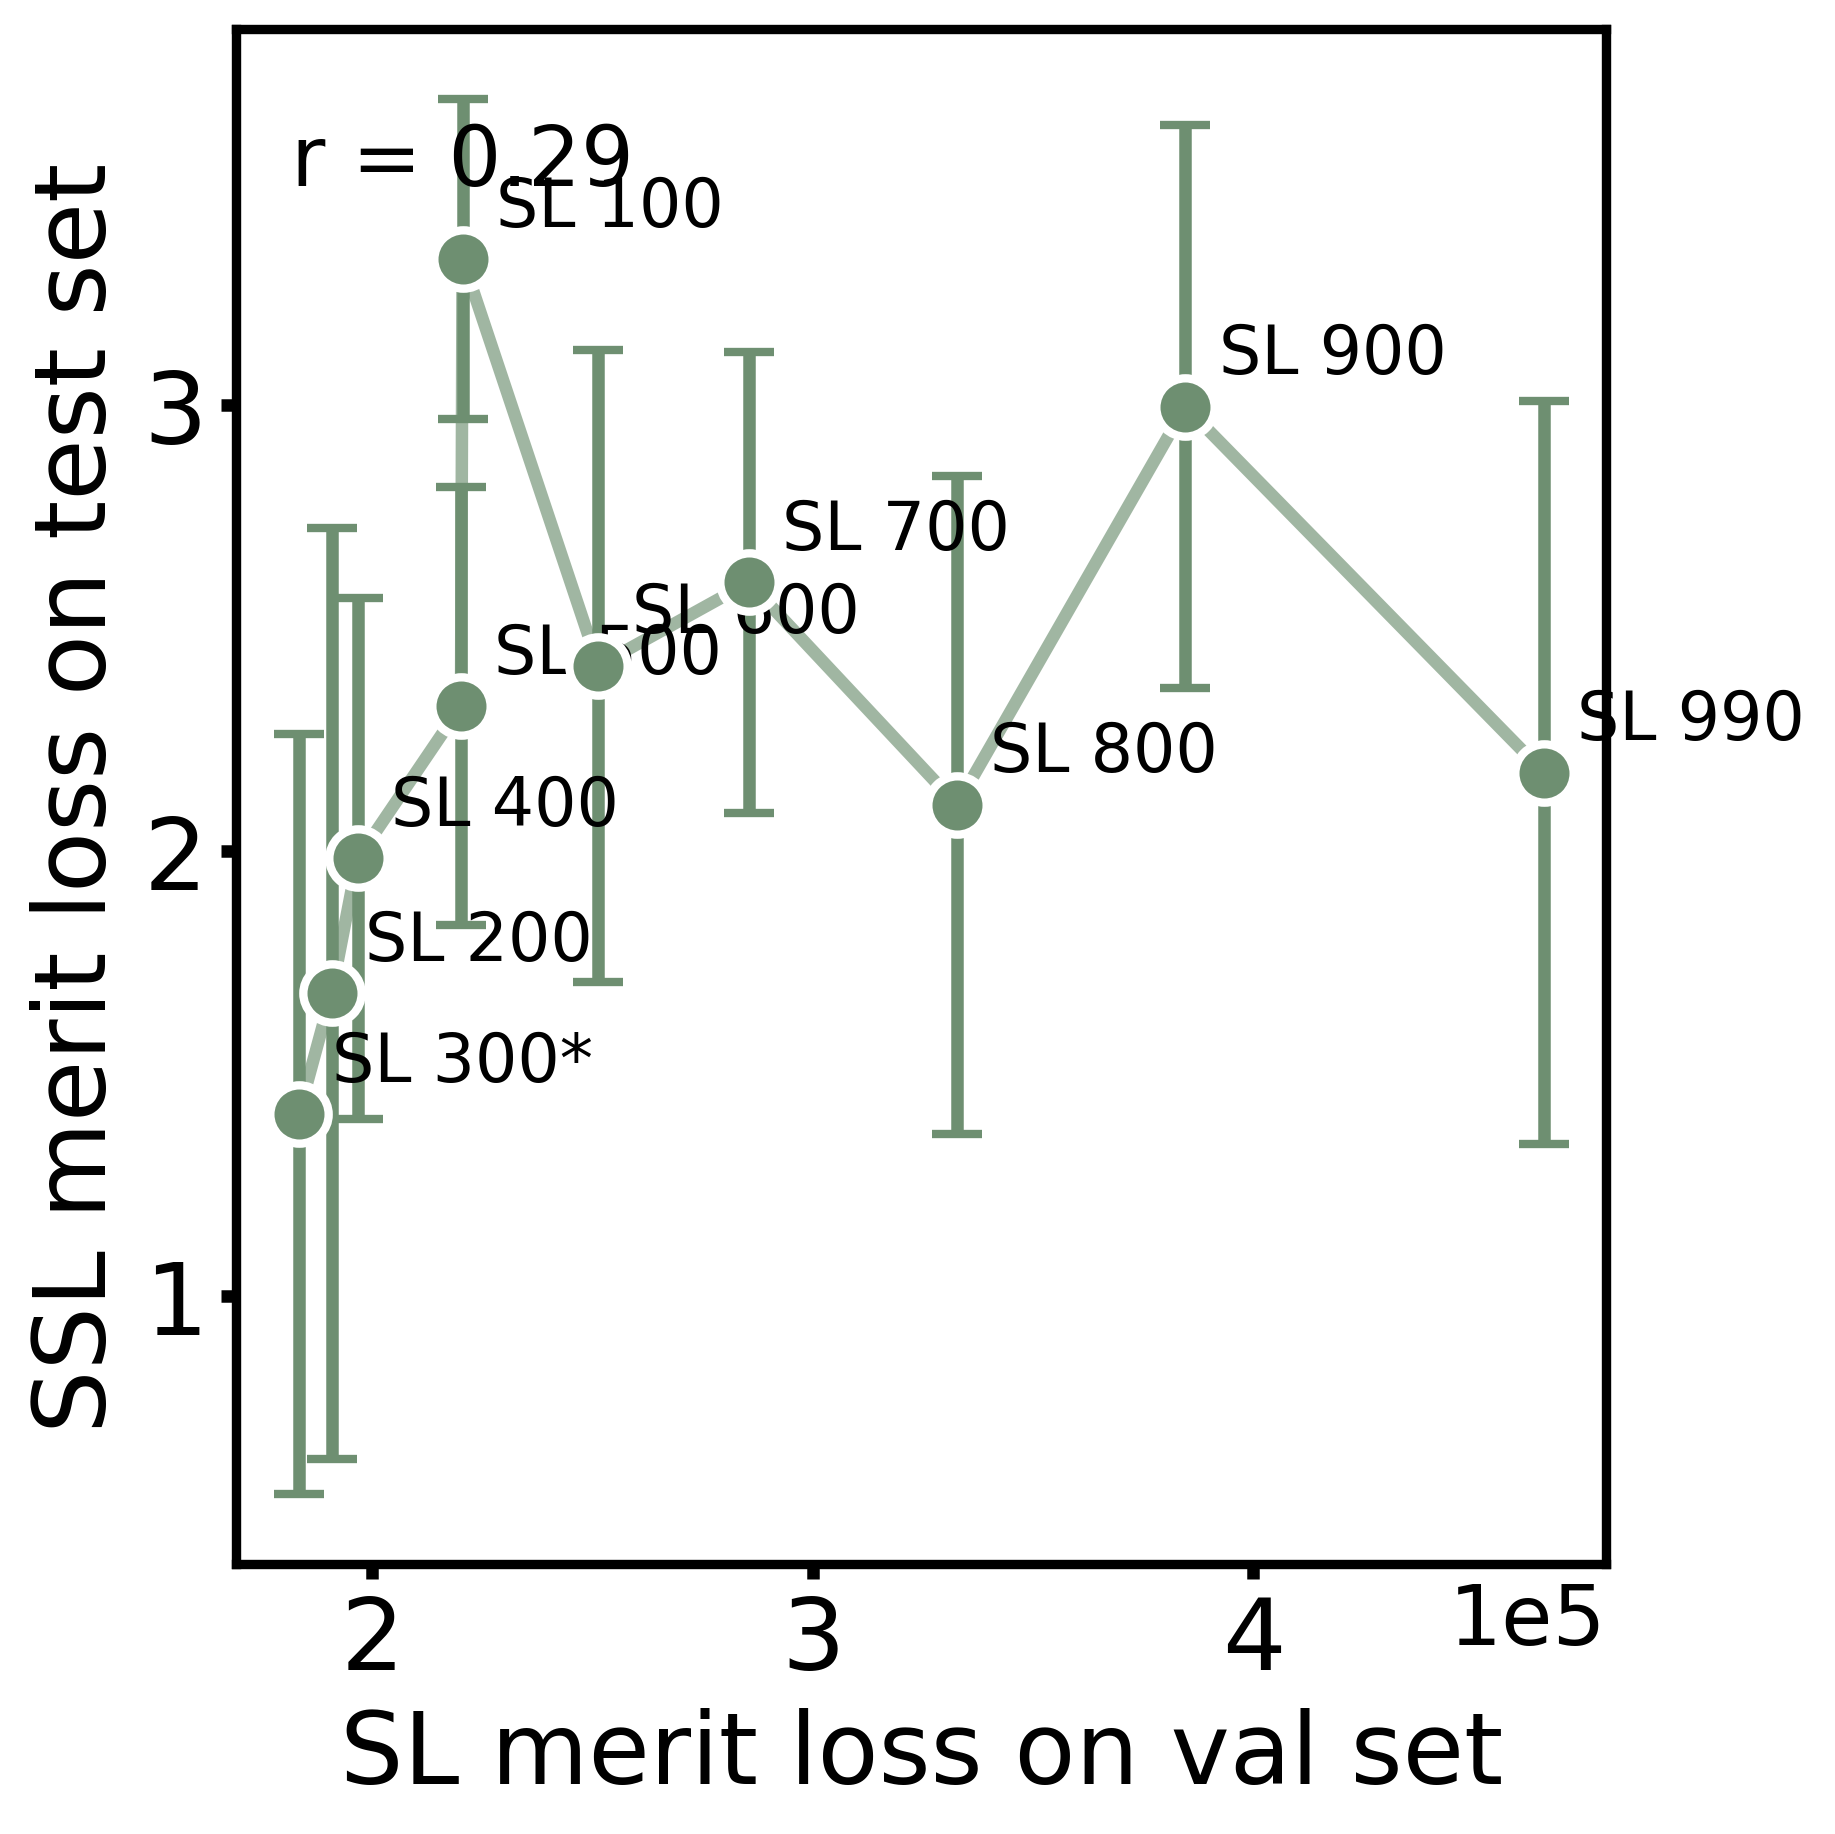

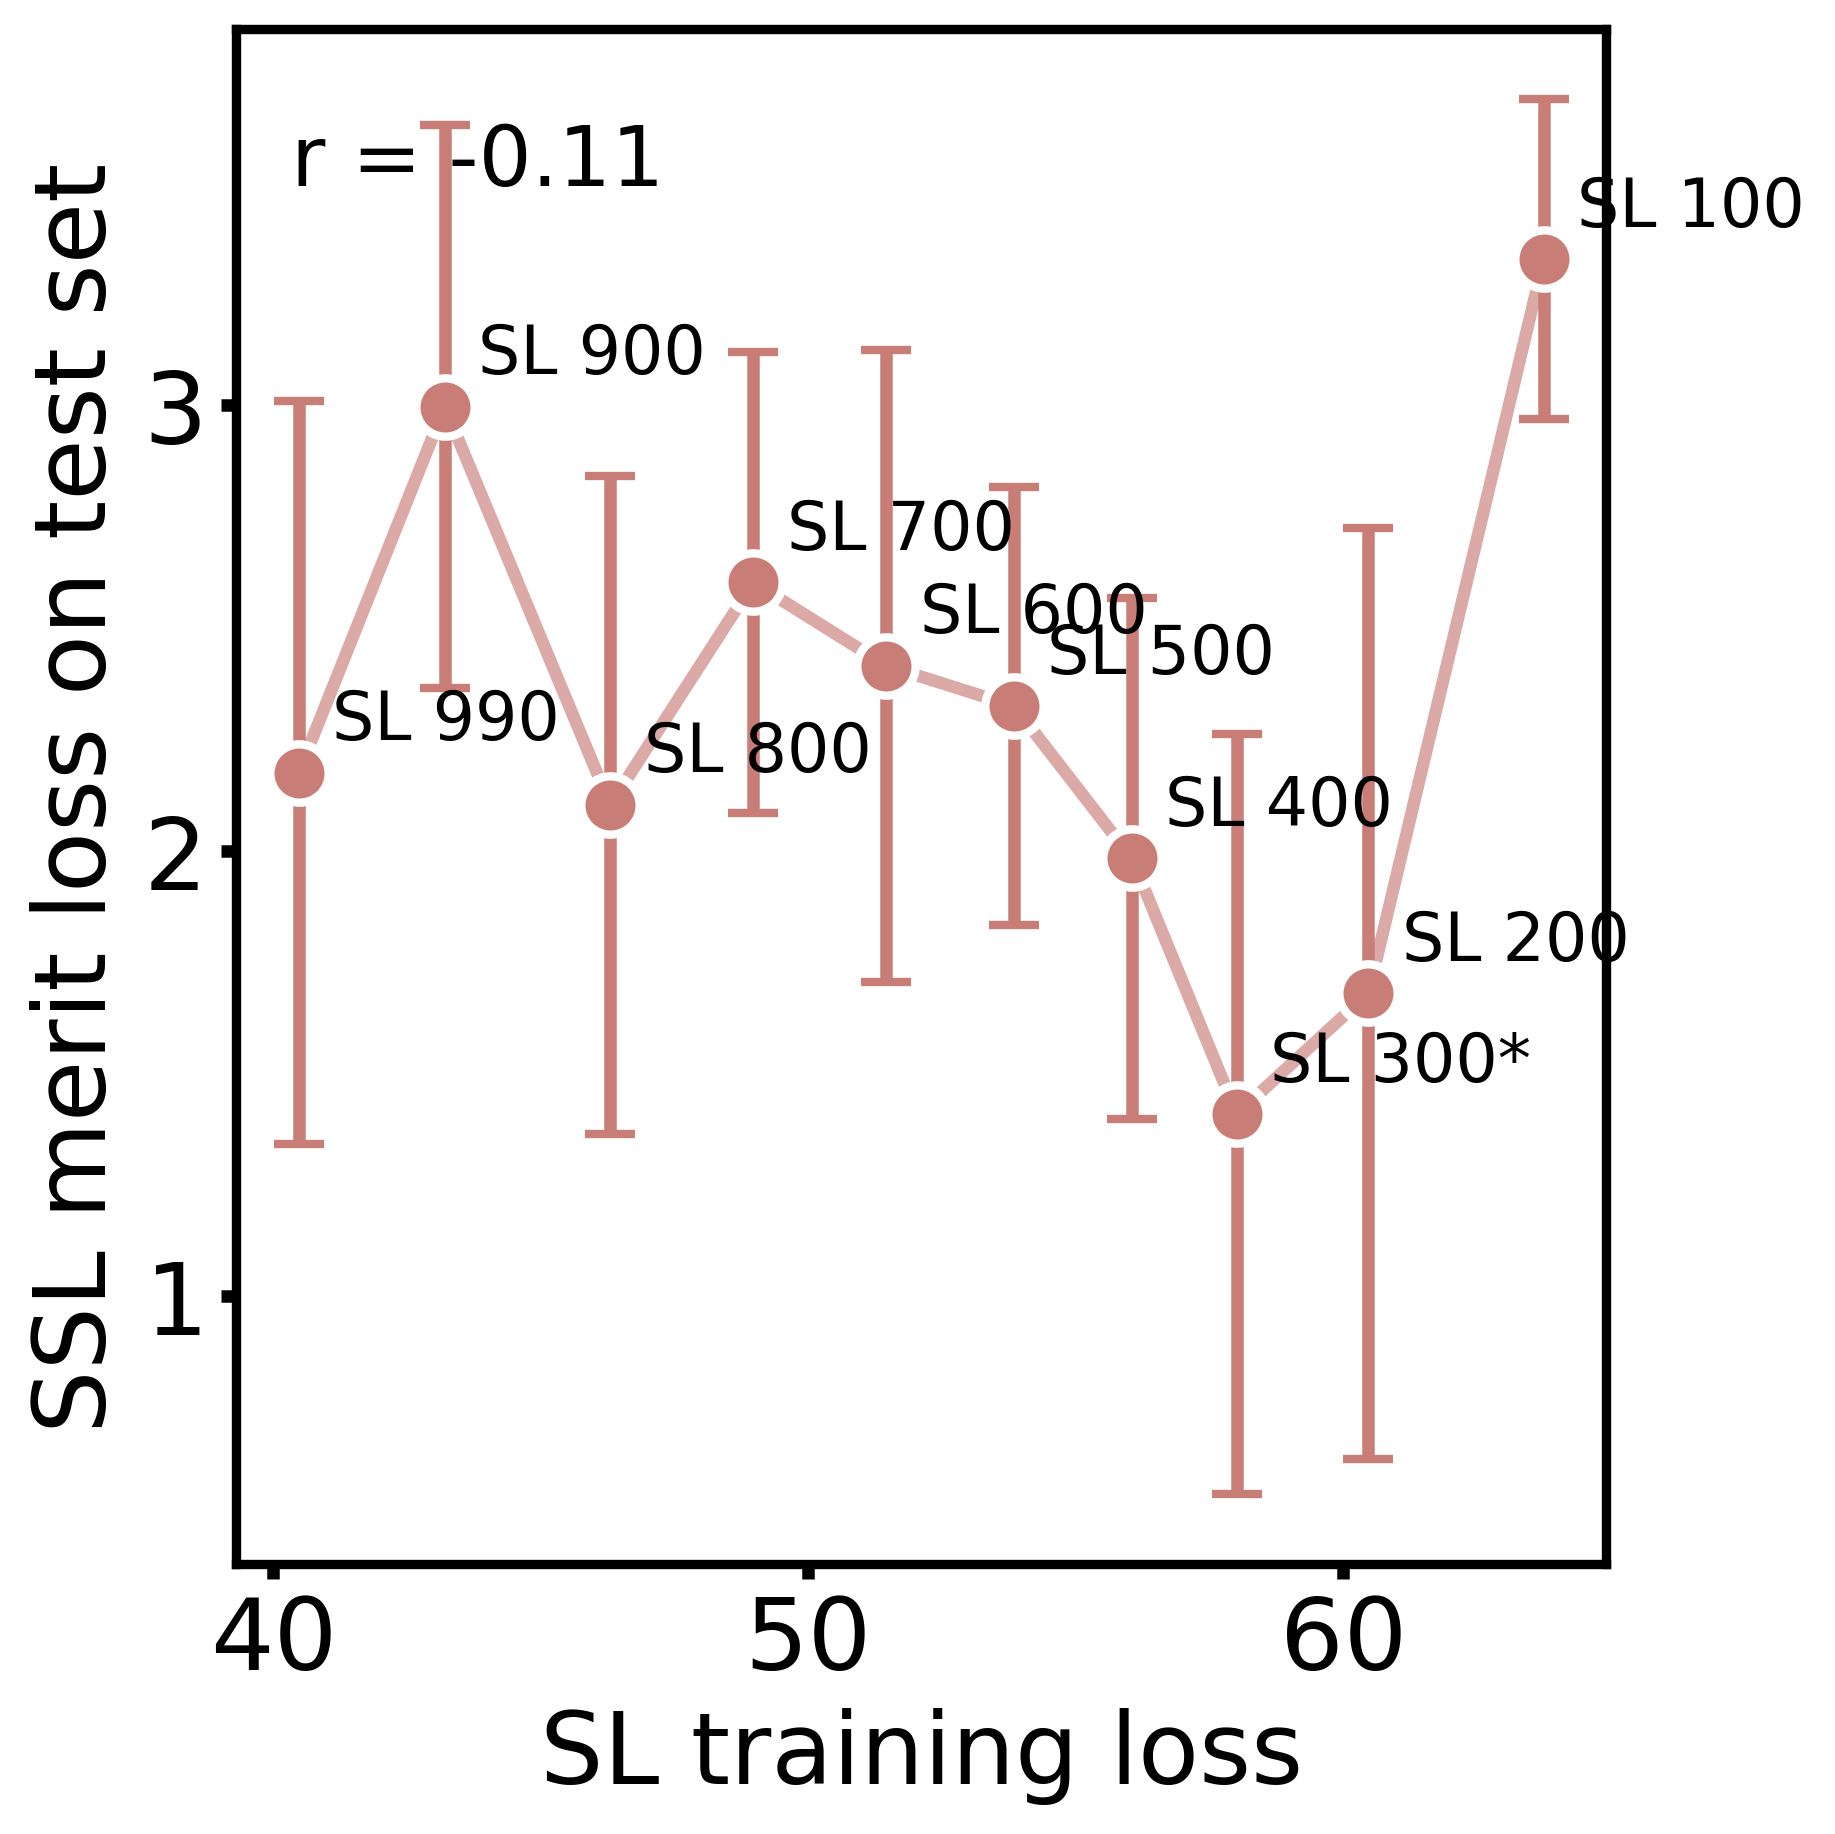

In [233]:
checkpoints = [
    ('SL 100', 'epoch 100', 100),
    ('SL 200', 'epoch 200', 200),
    ('SL 300*', 'epoch 300*', 300),
    ('SL 400', 'epoch 400', 400),
    ('SL 500', 'epoch 500', 500),
    ('SL 600', 'epoch 600', 600),
    ('SL 700', 'epoch 700', 700),
    ('SL 800', 'epoch 800', 800),
    ('SL 900', 'epoch 900', 900),
    ('SL 990', 'epoch 990', 990),
]

plot_sl_to_ssl_merit_transfer(
    main_result_path,
    BASE_DIR,
    processed_data,
    metric_name='recomputed_merit_mean',
    checkpoints=checkpoints,
)
plot_sl_train_loss_to_ssl_merit_transfer(
    main_result_path,
    BASE_DIR,
    processed_data,
    metric_name='recomputed_merit_mean',
    checkpoints=checkpoints,
)
